In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nltk
import string

In [ ]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 0
true_df["label"] = 1

merged_news = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

In [ ]:
len(fake_df), len(true_df)

(23481, 21417)

In [ ]:
merged_news.sample(5)

,title,text,subject,date,label
34941,"China punishes over 8,000 people for misuse of...","SHANGHAI (Reuters) - China has punished 8,123 ...",worldnews,"December 23, 2017",1
33872,Rubio campaign urges supporters in Ohio to bac...,WASHINGTON (Reuters) - U.S. Republican preside...,politicsNews,"March 11, 2016",1
12021,CHECK OUT TRUMP’S HILARIOUS New Years Eve Twee...,"Whether they like it or not, Trump continues t...",politics,"Jan 1, 2017",0
7279,Which GOP Candidate Is The Least Worst? Bill ...,Are you having a hard time figuring out whethe...,News,"March 26, 2016",0
2815,Trump’s Approval Rating Drops AGAIN To New Re...,Gallup Polling recently had Donald Trump s app...,News,"January 27, 2017",0


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.0 MB/s eta 0:00:00


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
#from gensim.models.doc2vec import Doc2Vec, TaggedDocument

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MAINAK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MAINAK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MAINAK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def clean_text(doc):
    tokens = word_tokenize(doc)  # tokenize
    table = str.maketrans('', '', string.punctuation)
    tokens = [w.translate(table) for w in tokens]  # remove punctuation
    tokens = [word.lower() for word in tokens if word.isalpha()]  # keep only alphabetic
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # remove stopwords
    return tokens

In [2]:
merged_news['text_tokens'] = merged_news['text'].apply(clean_text)
merged_news.sample(5)

NameError: name 'merged_news' is not defined

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd /content/drive/MyDrive/Fake\ News\ Detection

/content/drive/MyDrive/Fake News Detection


In [ ]:
# import os
# os.listdir()
#merged_news=pd.read_csv('tokenized_merged_news.csv')

In [ ]:
merged_news.sample(5)

,title,text,subject,date,label,text_tokens
7761,This One Tweet Explains How Close Trump Is To...,Americans like to sit back and smugly announce...,News,"March 1, 2016",0,"['americans', 'like', 'sit', 'back', 'smugly',..."
3102,WATCH: Jimmy Fallon Takes HILARIOUS Dig At Tr...,Tonight s the night of the Golden Globe Awards...,News,"January 8, 2017",0,"['tonight', 'night', 'golden', 'globe', 'award..."
40460,Exiled Venezuelan opposition magistrates resur...,SANTIAGO (Reuters) - A group of opposition-app...,worldnews,"October 19, 2017",1,"['santiago', 'reuters', 'group', 'oppositionap..."
40731,"Fruit, prawns off the menu at China's austere ...",BEIJING (Reuters) - No free fruit in hotel roo...,worldnews,"October 15, 2017",1,"['beijing', 'reuters', 'free', 'fruit', 'hotel..."
26837,Trump to give remarks on healthcare at 12:55 p...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"June 7, 2017",1,"['washington', 'reuters', 'president', 'donald..."


In [5]:
X=merged_news['text_tokens']
y=merged_news['label']

In [6]:
from sklearn.model_selection import train_test_split

# Step 1: Split into train (80%) and test (20%)
X_train, X_test,y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2500,ngram_range=(1,2))

In [ ]:
X_train=cv.fit_transform(X_train).toarray()
X_test=cv.transform(X_test).toarray()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

param_grid= { 'C': [0.01,0.1,1,10,100]
             }

model=LogisticRegression(penalty='l2', solver='liblinear',
                         max_iter=1000

)

grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1

)

grid.fit(X_train,y_train)

best_model=grid.best_estimator_

print("Best C and solver:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Best C and solver: {'C': 0.1}
Best CV score: 0.995489725803346
Test Accuracy: 0.9962138084632517

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

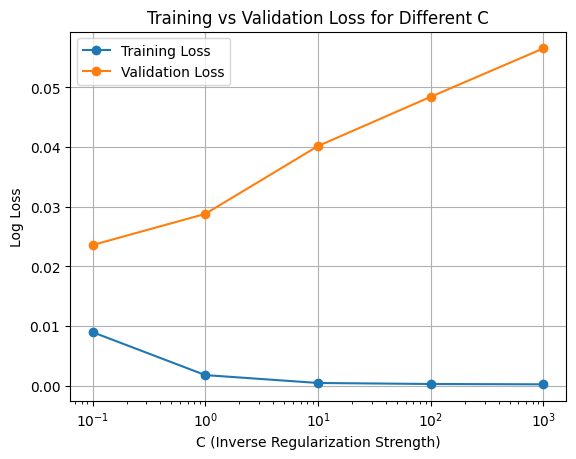

In [ ]:
from sklearn.metrics import log_loss


# C values (inverse of lambda)
C_values = [1000, 100, 10, 1, 0.1]

train_losses = []
val_losses = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_train, y_train)

    # Predict probabilities (needed for log loss)
    y_train_prob = model.predict_proba(X_train)
    y_val_prob = model.predict_proba(X_test)

    # Compute loss
    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_test, y_val_prob)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot
plt.figure()
plt.plot(C_values, train_losses, marker='o', label='Training Loss')
plt.plot(C_values, val_losses, marker='o', label='Validation Loss')

plt.xscale('log')  # important for C
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different C')
plt.legend()
plt.grid()

plt.show()

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.9962138084632517
Precision: 0.9955690298507462
Recall: 0.9964985994397759
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



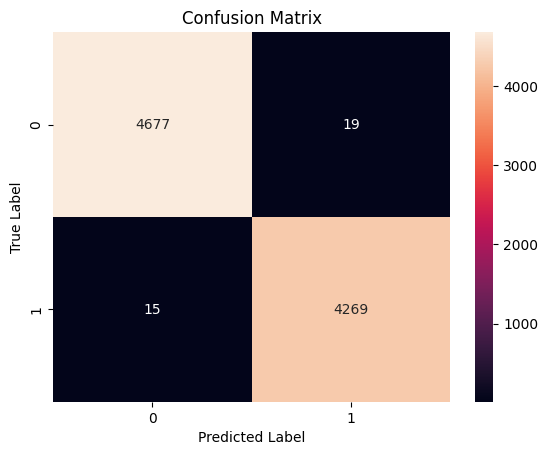

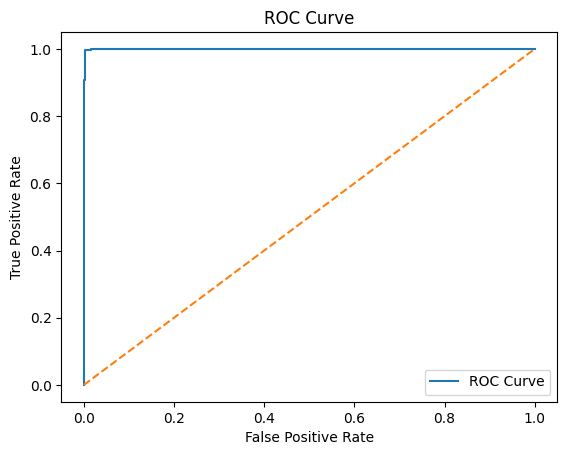

ROC-AUC: 0.998789670609868


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# train logistic regression with chosen C
model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc_score)

TF_IDF


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
X=merged_news['text_tokens']
y=merged_news['label']
#train_test_split before tf_idf vectorization
from sklearn.model_selection import train_test_split

# Step 1: Split into train (80%) and test (20%)
X_train, X_test,y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
tfidf = TfidfVectorizer()


tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

param_grid= { 'C': [0.01,0.1,1,10,100]
             }

model=LogisticRegression(penalty='l2', solver='liblinear',
                         max_iter=1000

)

grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1

)

grid.fit(X_tfidf,y_train)

best_model=grid.best_estimator_

print("Best C and solver:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Best C and solver: {'C': 100}
Best CV score: 0.9921208576176055
Test Accuracy: 0.9943207126948775

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

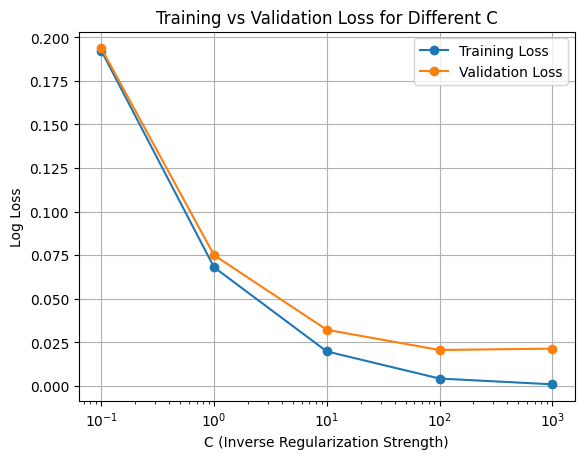

In [ ]:
from sklearn.metrics import log_loss


# C values (inverse of lambda)
C_values = [ 1000,100,10,1, 0.1]

train_losses = []
val_losses = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_tfidf, y_train)

    # Predict probabilities (needed for log loss)
    y_train_prob = model.predict_proba(X_tfidf)
    y_val_prob = model.predict_proba(X_test_tfidf)

    # Compute loss
    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_test, y_val_prob)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot
plt.figure()
plt.plot(C_values, train_losses, marker='o', label='Training Loss')
plt.plot(C_values, val_losses, marker='o', label='Validation Loss')

plt.xscale('log')  # important for C
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different C')
plt.legend()
plt.grid()

plt.show()

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.9710467706013363
Precision: 0.9659564613246874
Recall: 0.9736227824463118
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      4696
           1       0.97      0.97      0.97      4284

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



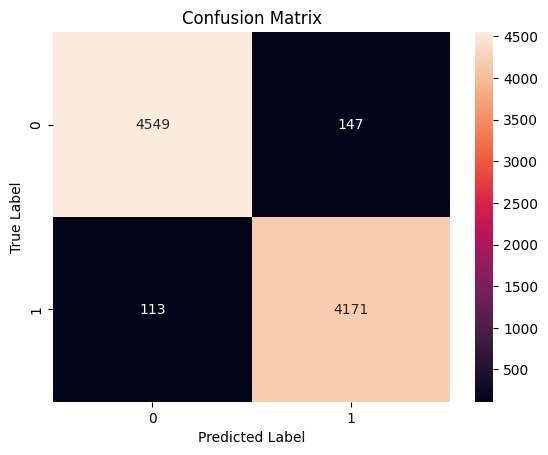

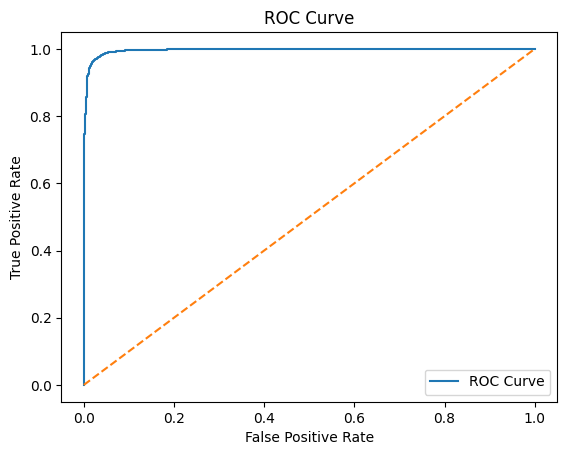

ROC-AUC: 0.9960077869875946


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# train logistic regression with chosen C
model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000)
model.fit(X_tfidf, y_train)

# predictions
y_pred = model.predict(X_test_tfidf)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc_score)

WORD2VEC

In [ ]:
!pip install gensim

  Using cached smart_open-7.5.1-py3-none-any.whl.metadata (24 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 5.6 MB/s eta 0:00:05
   -------- ------------------------------- 5.0/24.4 MB 17.7 MB/s eta 0:00:02
   ---------------- ----------------------- 10.0/24.4 MB 21.4 MB/s eta 0:00:01
   ---------------------- ----------------- 13.6/24.4 MB 19.9 MB/s eta 0:00:01
   ----------------------------- ---------- 18.1/24.4 MB 20.4 MB/s eta 0:00:01
   -------------------------------------- - 23.6/24.4 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 20.1 MB/s  0:00:01
Using cached smart_open-7.5.1-py3-none-any.whl (64 kB)

   ---------------------------------------- 0/2 [smart_open]
   ---------------------------------------- 0/2 [smart_open]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- -

In [ ]:
X=merged_news['text_tokens']
y=merged_news['label']
#train_test_split before word2vec vectorization
from sklearn.model_selection import train_test_split

# Step 1: Split into train (80%) and test (20%)
X_train, X_test,y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=100,   # embedding dimension
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
def sentence_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [ ]:
X_train_vec = np.array([sentence_vector(tokens, w2v_model) for tokens in X_train])
X_test_vec  = np.array([sentence_vector(tokens, w2v_model) for tokens in X_test])

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report

param_grid={'alpha':[0.1,0.5,1,2]

}
model=BernoulliNB()
grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1)
grid.fit(X_train_vec,y_train)
best_model=grid.best_estimator_

print("Best C:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test_vec)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best C: {'alpha': 2}
Best CV score: 0.6237262209987886
Test Accuracy: 0.6285077951002227

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.39      0.53      4696
           1       0.57      0.89      0.69      4284

    accuracy                           0.63      8980
   macro avg       0.68      0.64      0.61      8980
weighted avg       0.69      0.63      0.61      8980



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report

param_grid={'var_smoothing': np.logspace(-12, -6, 7)

}
model=GaussianNB()
grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1)
grid.fit(X_train_vec,y_train)
best_model=grid.best_estimator_

print("Best C:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test_vec)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best C: {'var_smoothing': np.float64(1e-12)}
Best CV score: 0.5180690527033174
Test Accuracy: 0.5146993318485523

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.08      0.14      4696
           1       0.50      0.99      0.66      4284

    accuracy                           0.51      8980
   macro avg       0.72      0.54      0.40      8980
weighted avg       0.73      0.51      0.39      8980



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel='rbf',gamma=0.1))
])

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_vec, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

y_pred = grid.predict(X_test_vec)

Best Params: {'svc__C': 10}
Best CV Score: 0.8216494990802026


In [ ]:
from sklearn.svm import SVC
model=SVC(C=10)
model.fit(X_train_vec,y_train)
y_pred=model.predict(X_test_vec)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7733853006681515

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78      4696
           1       0.76      0.78      0.77      4284

    accuracy                           0.77      8980
   macro avg       0.77      0.77      0.77      8980
weighted avg       0.77      0.77      0.77      8980



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

param_grid= { 'C': [0.01,0.1,1,10,100]
             }

model=LogisticRegression(penalty='l2', solver='liblinear',
                         max_iter=1000

)

grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1

)

grid.fit(X_train_vec,y_train)

best_model=grid.best_estimator_

print("Best C and solver:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test_vec)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Best C and solver: {'C': 100}
Best CV score: 0.7844258529868375
Test Accuracy: 0.773608017817372

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78      4696
           1       0.76      0.76      0.76      4284

    accuracy                           0.77      8980
   macro avg       0.77      0.77      0.77      8980
weighted avg       0.77      0.77      0.77      8980



c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

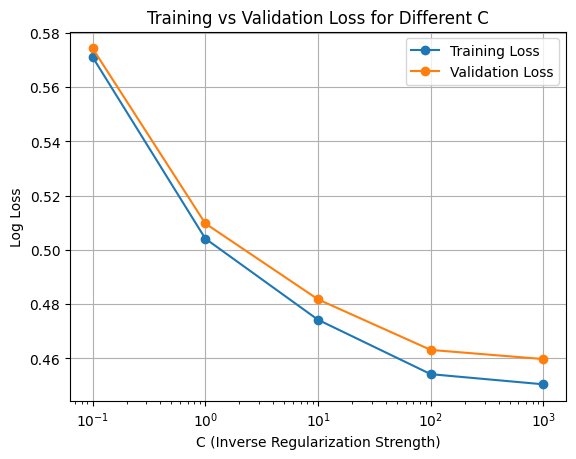

In [ ]:
from sklearn.metrics import log_loss


# C values (inverse of lambda)
C_values = [ 1000,100,10,1, 0.1]

train_losses = []
val_losses = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_train_vec, y_train)

    # Predict probabilities (needed for log loss)
    y_train_prob = model.predict_proba(X_train_vec)
    y_val_prob = model.predict_proba(X_test_vec)

    # Compute loss
    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_test, y_val_prob)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot
plt.figure()
plt.plot(C_values, train_losses, marker='o', label='Training Loss')
plt.plot(C_values, val_losses, marker='o', label='Validation Loss')

plt.xscale('log')  # important for C
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different C')
plt.legend()
plt.grid()

plt.show()

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.7689309576837416
Precision: 0.7565621370499419
Recall: 0.7602707749766573
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4696
           1       0.76      0.76      0.76      4284

    accuracy                           0.77      8980
   macro avg       0.77      0.77      0.77      8980
weighted avg       0.77      0.77      0.77      8980



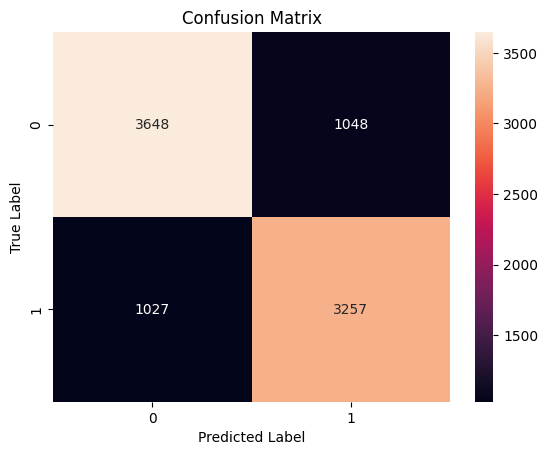

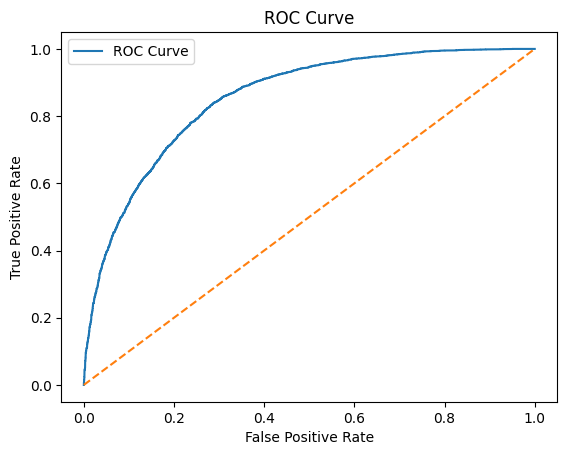

ROC-AUC: 0.852973237847098


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# train logistic regression with chosen C
model = LogisticRegression(C=100, penalty='l2', solver='lbfgs', max_iter=1000)
model.fit(X_train_vec, y_train)

# predictions
y_pred = model.predict(X_test_vec)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict_proba(X_test_vec)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc_score)

DOC2VEC

In [ ]:
X=merged_news['text_tokens']
y=merged_news['label']
#train_test_split before word2vec vectorization
from sklearn.model_selection import train_test_split

# Step 1: Split into train (80%) and test (20%)
X_train, X_test,y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from gensim.models.doc2vec import TaggedDocument


# Tag training documents
train_tagged = [
    TaggedDocument(words=tokens, tags=[i])
    for i, tokens in enumerate(X_train)
]

In [ ]:
from gensim.models import Doc2Vec

doc2vec_model = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=100
)

doc2vec_model.build_vocab(train_tagged)
doc2vec_model.train(
    train_tagged,
    total_examples=doc2vec_model.corpus_count,
    epochs=doc2vec_model.epochs
)

In [ ]:
doc2vec_model.save("doc2vec.model")

In [ ]:
from gensim.models import Doc2Vec
doc2vec_model = Doc2Vec.load("doc2vec.model")

In [ ]:
X_train_vec = [doc2vec_model.dv[i] for i in range(len(X_train))]
# X_test_vec = [
#     doc2vec_model.infer_vector(tokens)
#     for tokens in X_test
# ]

In [ ]:
import ast

X_test_tokens = X_test.apply(ast.literal_eval)

In [ ]:
X_test_vec = [
    doc2vec_model.infer_vector(tokens)
    for tokens in X_test_tokens
]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,precision_score,recall_score

param_grid= { 'C': [0.01,0.1,1,10,100]
             }

model=LogisticRegression(penalty='l2', solver='liblinear',
                         max_iter=1000

)

grid=GridSearchCV(estimator=model,
                  param_grid=param_grid,
                  cv=5, scoring='accuracy',
                  n_jobs=1

)

grid.fit(X_train_vec,y_train)

best_model=grid.best_estimator_

print("Best C and solver:",grid.best_params_)
print("Best CV score:",grid.best_score_)

y_pred=best_model.predict(X_test_vec)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Best C and solver: {'C': 10}
Best CV score: 0.7119003915146098
Test Accuracy: 0.5226057906458798

Classification Report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.69      4696
           1       0.20      0.00      0.00      4284

    accuracy                           0.52      8980
   macro avg       0.36      0.50      0.34      8980
weighted avg       0.37      0.52      0.36      8980



c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

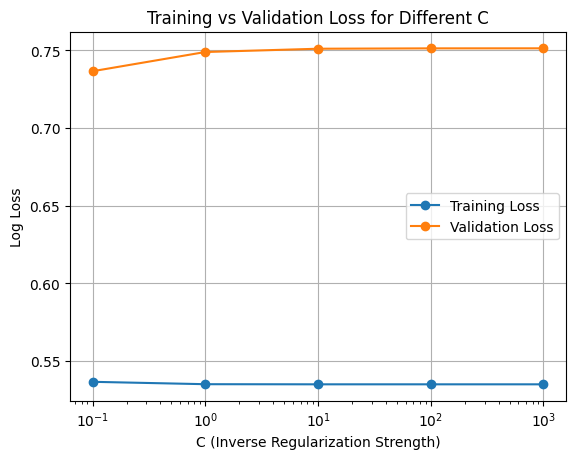

In [ ]:
from sklearn.metrics import log_loss


# C values (inverse of lambda)
C_values = [ 1000,100,10,1, 0.1]

train_losses = []
val_losses = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l2',
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_train_vec, y_train)

    # Predict probabilities (needed for log loss)
    y_train_prob = model.predict_proba(X_train_vec)
    y_val_prob = model.predict_proba(X_test_vec)

    # Compute loss
    train_loss = log_loss(y_train, y_train_prob)
    val_loss = log_loss(y_test, y_val_prob)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot
plt.figure()
plt.plot(C_values, train_losses, marker='o', label='Training Loss')
plt.plot(C_values, val_losses, marker='o', label='Validation Loss')

plt.xscale('log')  # important for C
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different C')
plt.legend()
plt.grid()

plt.show()

Accuracy: 0.5226057906458798
Precision: 0.2
Recall: 0.00023342670401493932
              precision    recall  f1-score   support

           0       0.52      1.00      0.69      4696
           1       0.20      0.00      0.00      4284

    accuracy                           0.52      8980
   macro avg       0.36      0.50      0.34      8980
weighted avg       0.37      0.52      0.36      8980



c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


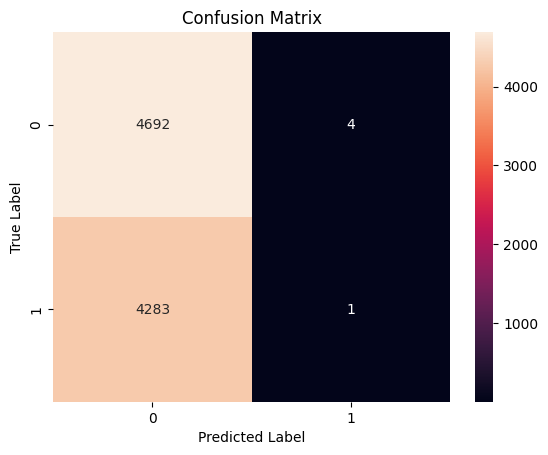

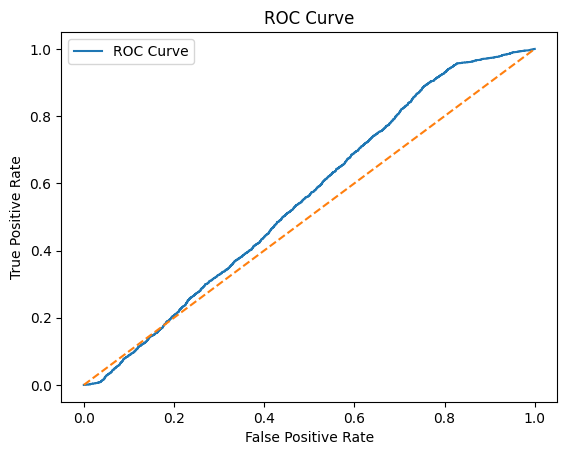

ROC-AUC: 0.5533723497917055


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# train logistic regression with chosen C
model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000)
model.fit(X_train_vec, y_train)

# predictions
y_pred = model.predict(X_test_vec)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict_proba(X_test_vec)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ROC AUC
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc_score)

In [ ]:
X_train_vec = np.array(X_train_vec)
y_train = np.array(y_train)
X_test_vec=np.array(X_test_vec)
y_test=np.array(y_test)

In [ ]:
print(X_train_vec.shape)
print(y_train.shape)

(35918, 100)
(35918,)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(100,)))   # 100 features (Doc2Vec vector)

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,249 (83.00 KB)

 Trainable params: 21,249 (83.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train_vec,y_train,epochs=50)

Epoch 1/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7390 - loss: 0.5234
Epoch 2/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.7783 - loss: 0.4672
Epoch 3/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - accuracy: 0.7949 - loss: 0.4423
Epoch 4/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.8064 - loss: 0.4227
Epoch 5/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step - accuracy: 0.8144 - loss: 0.4070
Epoch 6/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 955us/step - accuracy: 0.8220 - loss: 0.3915
Epoch 7/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.8307 - loss: 0.3768
Epoch 8/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - accuracy: 0.8391 - loss: 0.3615
Epoch 9/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.8461 - loss: 0.3473
Epoch 10/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step - accuracy: 0.8516 - loss: 0.3339
Epoch 11/50
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 932us/step - accuracy: 0.8605 - loss: 0.3207
Epoch 12/5

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step
Accuracy: 0.5185968819599109
Precision: 0.27586206896551724
Recall: 0.0056022408963585435
              precision    recall  f1-score   support

           0       0.52      0.99      0.68      4696
           1       0.28      0.01      0.01      4284

    accuracy                           0.52      8980
   macro avg       0.40      0.50      0.35      8980
weighted avg       0.40      0.52      0.36      8980



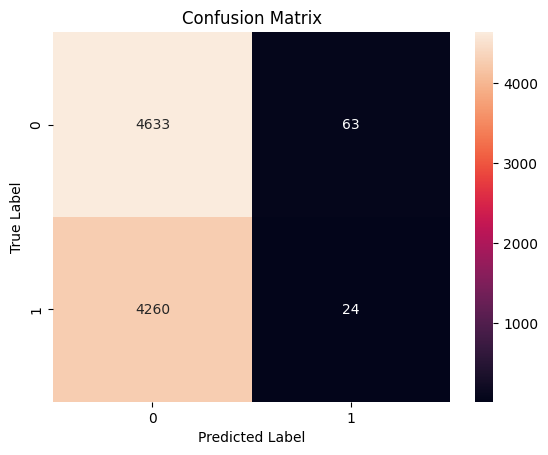

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step


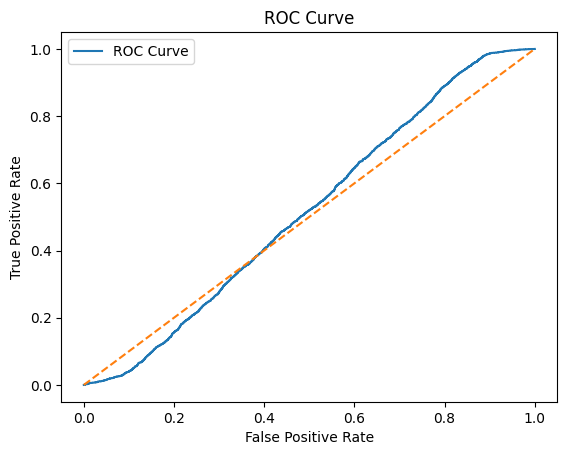

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score
y_pred=model.predict(X_test_vec)
y_pred = (y_pred > 0.5).astype(int)
# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict(X_test_vec).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

In [9]:
max_len=max(len(x) for x in X_train)
print(max_len)

52434


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=2000)

# Join tokens back to text if needed
X_train_text = [" ".join(x) for x in X_train]
X_test_text  = [" ".join(x) for x in X_test]

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

In [8]:
import numpy as np

lengths = [len(x) for x in X_train_seq]

print("Max:", max(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("90th percentile:", np.percentile(lengths, 90))

Max: 43146
95th percentile: 4447.0
90th percentile: 3610.2999999999993


In [9]:
max_len = int(np.percentile(lengths, 95))

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post')

In [11]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Input

model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=2000, output_dim=25))
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4447, 25)       │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,977 (503.82 KB)

 Trainable params: 128,977 (503.82 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(X_train_pad,y_train,epochs=20)

Epoch 1/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 167s 141ms/step - accuracy: 0.5234 - loss: 0.6957
Epoch 2/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 152s 135ms/step - accuracy: 0.5221 - loss: 0.6908
Epoch 3/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 151s 135ms/step - accuracy: 0.5248 - loss: 0.6882
Epoch 4/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 152s 135ms/step - accuracy: 0.5240 - loss: 0.6858
Epoch 5/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 202s 135ms/step - accuracy: 0.5276 - loss: 0.6846
Epoch 6/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 202s 135ms/step - accuracy: 0.5246 - loss: 0.6839
Epoch 7/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 152s 135ms/step - accuracy: 0.5286 - loss: 0.6828
Epoch 8/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 155s 138ms/step - accuracy: 0.5322 - loss: 0.6817
Epoch 9/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 154s 137ms/step - accuracy: 0.5318 - loss: 0.6807
Epoch 10/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 153s 136ms/step - accuracy: 0.5342 - loss: 0.6790
Epoch 11/20
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 155s 138ms/step - accuracy: 0.5344 -

281/281 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step
Accuracy: 0.9048997772828508
Precision: 0.8819599109131403
Recall: 0.9243697478991597
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      4696
           1       0.88      0.92      0.90      4284

    accuracy                           0.90      8980
   macro avg       0.90      0.91      0.90      8980
weighted avg       0.91      0.90      0.90      8980



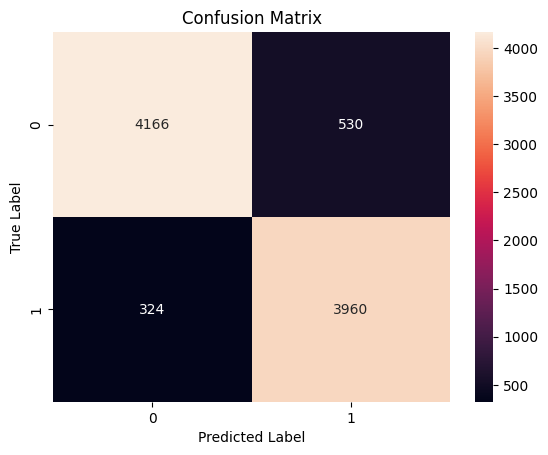

281/281 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step


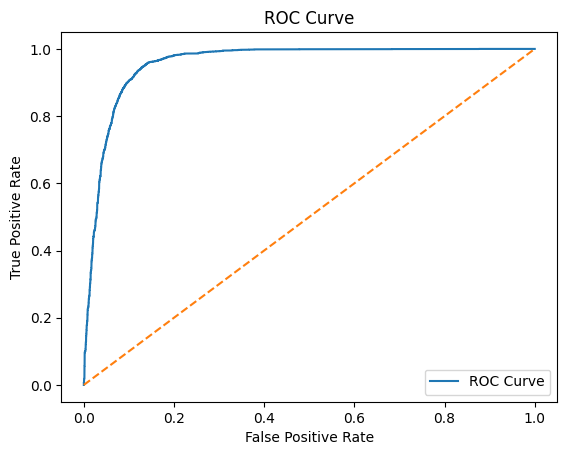

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,classification_report
from sklearn.metrics import roc_curve, roc_auc_score
y_pred=model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)
# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
pre = precision_score(y_test, y_pred)
print("Precision:",pre )
recall = recall_score(y_test, y_pred)
print("Recall:",recall )
print(classification_report(y_test,y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# ROC curve
y_prob = model.predict(X_test_pad).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()


In [17]:
auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc_score)

ROC-AUC: 0.9575638851508803


In [19]:
model.save("lstm_model.keras")

In [22]:
from tensorflow.keras.models import load_model
model = load_model("lstm_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
import os
print(os.listdir())

['True.csv', 'Fake.csv', 'tokenized_merged_news.csv', 'doc2vec.model', 'desktop.ini', 'Fake_news_detection_25BM6JP28.ipynb', 'lstm_model.h5', 'lstm_model.keras']
